# ROSE-1 SVC — Architecture Ablation (Evaluation)

Scores all 10 trained configs (5 variants x raw/preprocessed) on the 9 held-out
test images: mean +/- std across the 5 folds via evaluate_on_test. Then a
gap-to-std view flagging which variants clear the noise floor vs. tie the plain
unet, and a side-by-side prediction image on one test case.

Kernel runs on Oscar (Open OnDemand) in the octa-seg env. Inference is light,
CPU is fine.

In [2]:
import sys
sys.path.append('/users/egottfri/code/octa-segmentation/src')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from test_model import evaluate_on_test

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
N_FOLDS    = 5
VARIANTS   = ["unet", "attention_unet", "res_unet", "se_unet", "att_res_unet"]
CONDITIONS = ["raw", "preprocessed"]

RESULTS_DIR = Path("/users/egottfri/code/octa-segmentation/results/rose1_ablation")

ROSE1_BASE = Path("/files22_lrsresearch/ENG_Lee-Lab_Shared/group/data/public/rose_dataset/ROSE-1")
PREP_BASE  = Path("/users/egottfri/code/octa-segmentation/data/preprocessed")

test_masks = sorted((ROSE1_BASE / "SVC/test/gt").glob("*.tif"))
TEST_IMAGES = {
    "raw":          sorted((ROSE1_BASE / "SVC/test/img").glob("*.tif")),
    "preprocessed": sorted((PREP_BASE  / "SVC/test/img").glob("*.tif")),
}

def fold_paths(condition, name):
    return [str(RESULTS_DIR / condition / name / f"best_model_fold{i+1}.pth")
            for i in range(N_FOLDS)]

print(f"device: {DEVICE}, test images: {len(test_masks)}")

device: cpu, test images: 9


## Metrics table

evaluate_on_test averages each metric over the 9 test images per fold, then
reports mean +/- std across the 5 folds. One row per config. Saved to
results/rose1_ablation/summary.csv.

In [2]:
records = []   # keep raw floats too, for the gap-to-std cell
rows = []
for condition in CONDITIONS:
    te_imgs = TEST_IMAGES[condition]
    for name in VARIANTS:
        final, std = evaluate_on_test(te_imgs, test_masks, fold_paths(condition, name),
                                      device=DEVICE)
        records.append({"condition": condition, "model": name,
                        "final": final, "std": std})
        row = {"condition": condition, "model": name}
        row.update({m: f"{final[m]:.4f}±{std[m]:.4f}" for m in final})
        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(RESULTS_DIR / "summary.csv", index=False)
df

Fold 1: dice=0.7733, iou=0.6329, sensitivity=0.7635, specificity=0.9538, precision=0.7885, auprc=0.8649
Fold 2: dice=0.7784, iou=0.6399, sensitivity=0.7511, specificity=0.9608, precision=0.8132, auprc=0.8671
Fold 3: dice=0.7713, iou=0.6305, sensitivity=0.7782, specificity=0.9472, precision=0.7691, auprc=0.8662
Fold 4: dice=0.7746, iou=0.6350, sensitivity=0.7488, specificity=0.9586, precision=0.8068, auprc=0.8647
Fold 5: dice=0.7745, iou=0.6346, sensitivity=0.7517, specificity=0.9573, precision=0.8032, auprc=0.8663

TEST SET RESULTS (mean ± std across folds)
dice: 0.7744 ± 0.0023
iou: 0.6346 ± 0.0031
sensitivity: 0.7587 ± 0.0110
specificity: 0.9556 ± 0.0047
precision: 0.7962 ± 0.0158
auprc: 0.8658 ± 0.0009
Fold 1: dice=0.7724, iou=0.6319, sensitivity=0.7637, specificity=0.9520, precision=0.7853, auprc=0.8630
Fold 2: dice=0.7768, iou=0.6379, sensitivity=0.7477, specificity=0.9608, precision=0.8129, auprc=0.8658
Fold 3: dice=0.7723, iou=0.6317, sensitivity=0.7744, specificity=0.9483, prec

,condition,model,dice,iou,sensitivity,specificity,precision,auprc
0,raw,unet,0.7744±0.0023,0.6346±0.0031,0.7587±0.0110,0.9556±0.0047,0.7962±0.0158,0.8658±0.0009
1,raw,attention_unet,0.7732±0.0021,0.6330±0.0029,0.7626±0.0090,0.9533±0.0041,0.7888±0.0128,0.8647±0.0017
2,raw,res_unet,0.7802±0.0008,0.6424±0.0011,0.7411±0.0088,0.9651±0.0029,0.8287±0.0100,0.8718±0.0007
3,raw,se_unet,0.7720±0.0041,0.6313±0.0055,0.7586±0.0117,0.9543±0.0064,0.7915±0.0182,0.8612±0.0018
4,raw,att_res_unet,0.7799±0.0018,0.6420±0.0023,0.7425±0.0053,0.9644±0.0018,0.8261±0.0062,0.8712±0.0015
5,preprocessed,unet,0.7704±0.0011,0.6292±0.0014,0.7498±0.0097,0.9568±0.0040,0.7980±0.0125,0.8618±0.0020
6,preprocessed,attention_unet,0.7680±0.0019,0.6259±0.0026,0.7624±0.0087,0.9508±0.0038,0.7789±0.0116,0.8615±0.0020
7,preprocessed,res_unet,0.7758±0.0009,0.6364±0.0012,0.7405±0.0019,0.9627±0.0010,0.8199±0.0040,0.8702±0.0006
8,preprocessed,se_unet,0.7672±0.0024,0.6250±0.0032,0.7652±0.0047,0.9496±0.0029,0.7747±0.0094,0.8603±0.0013
9,preprocessed,att_res_unet,0.7737±0.0017,0.6335±0.0022,0.7428±0.0063,0.9607±0.0021,0.8126±0.0071,0.8667±0.0019


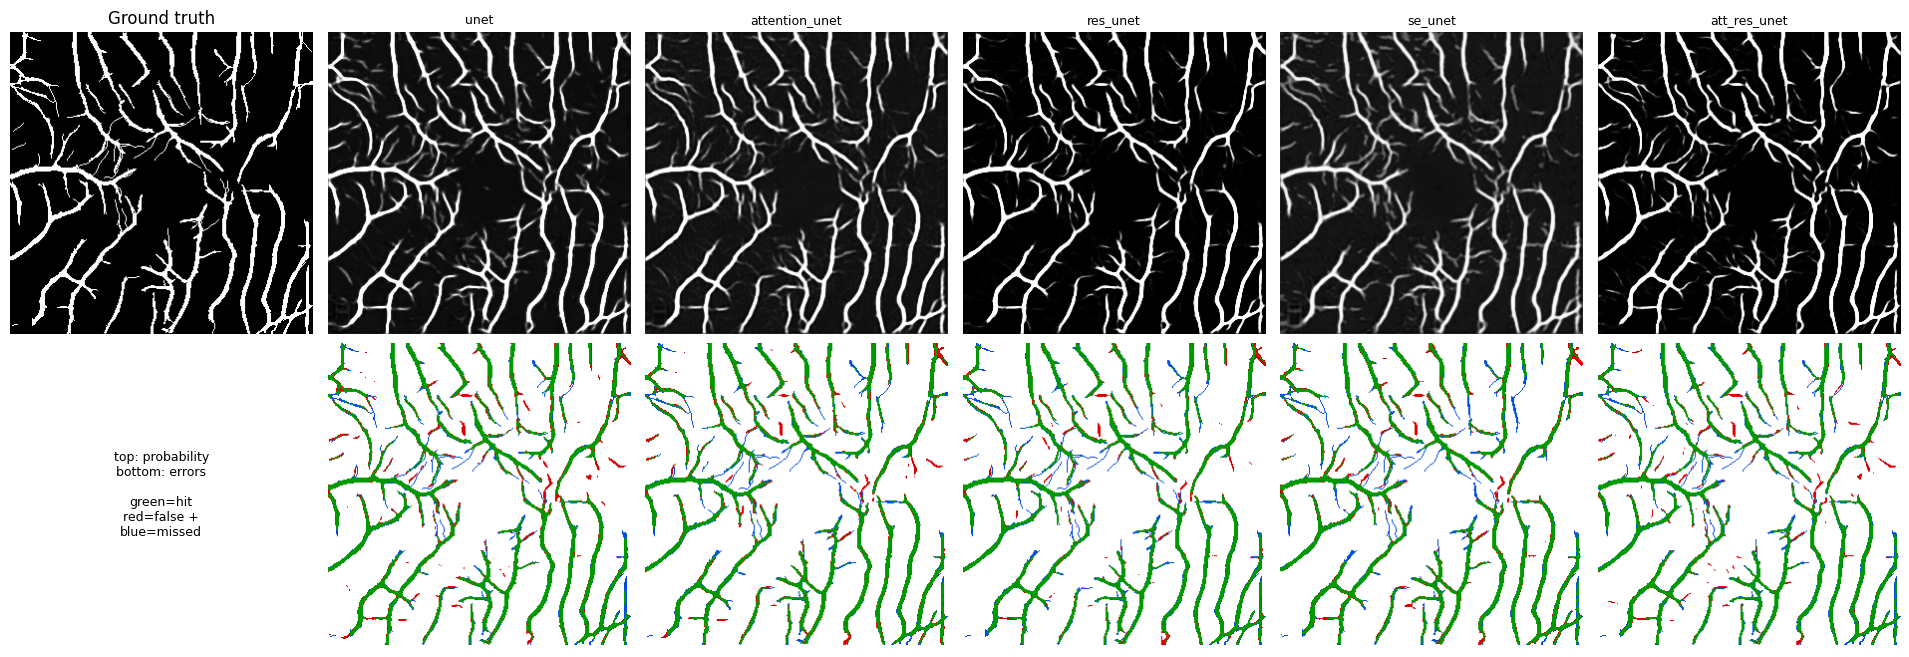

In [3]:
from dataset import OCTADataset
from model import build_model

VIZ_CONDITION = "raw"
VIZ_IDX  = 0
VIZ_FOLD = 1          # 1..N_FOLDS
THRESH   = 0.5

@torch.no_grad()
def predict_prob(ckpt_path, img_path, mask_path):
    ck = torch.load(ckpt_path, map_location=DEVICE)
    model = build_model(ck['model_name'], **ck['model_kwargs']).to(DEVICE)
    model.load_state_dict(ck['state_dict']); model.eval()
    x, gt = OCTADataset([img_path], [mask_path], augment=False)[0]
    prob = torch.sigmoid(model(x[None].to(DEVICE)))[0, 0].cpu().numpy()
    return prob, gt[0].numpy()

def error_rgb(pred, gt):
    """green=correct vessel (TP), red=false positive, blue=missed vessel (FN)."""
    h, w = gt.shape
    rgb = np.ones((h, w, 3))                      # white background
    tp = (pred == 1) & (gt == 1)
    fp = (pred == 1) & (gt == 0)
    fn = (pred == 0) & (gt == 1)
    rgb[tp] = [0.0, 0.6, 0.0]
    rgb[fp] = [0.85, 0.0, 0.0]
    rgb[fn] = [0.0, 0.3, 0.9]
    return rgb

img_path, mask_path = TEST_IMAGES[VIZ_CONDITION][VIZ_IDX], test_masks[VIZ_IDX]

fig, axes = plt.subplots(2, len(VARIANTS) + 1, figsize=(3.2 * (len(VARIANTS) + 1), 6.6))

_, gt = predict_prob(fold_paths(VIZ_CONDITION, VARIANTS[0])[VIZ_FOLD - 1], img_path, mask_path)
axes[0, 0].imshow(gt, cmap="gray"); axes[0, 0].set_title("Ground truth")
axes[1, 0].axis("off")
axes[0, 0].axis("off")

for j, name in enumerate(VARIANTS, start=1):
    prob, _ = predict_prob(fold_paths(VIZ_CONDITION, name)[VIZ_FOLD - 1], img_path, mask_path)
    pred = (prob > THRESH).astype(np.uint8)
    axes[0, j].imshow(prob, cmap="gray"); axes[0, j].set_title(name, fontsize=9)
    axes[0, j].axis("off")
    axes[1, j].imshow(error_rgb(pred, gt)); axes[1, j].axis("off")

axes[1, 0].text(0.5, 0.5, "top: probability\nbottom: errors\n\ngreen=hit\nred=false +\nblue=missed",
                ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f"example_{VIZ_CONDITION}_idx{VIZ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()